# BUAN381 Final Project — AI Adoption & Revenue Growth Prediction Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Data Loading

In [2]:
df = pd.read_csv('../dataset/ai_company_adoption.csv')
print(f"Shape: {df.shape}")
print(f"Nulls: {df.isnull().sum().sum()}")
df.head(3)

Shape: (150000, 43)
Nulls: 0


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation


## 2. Exploratory Data Analysis

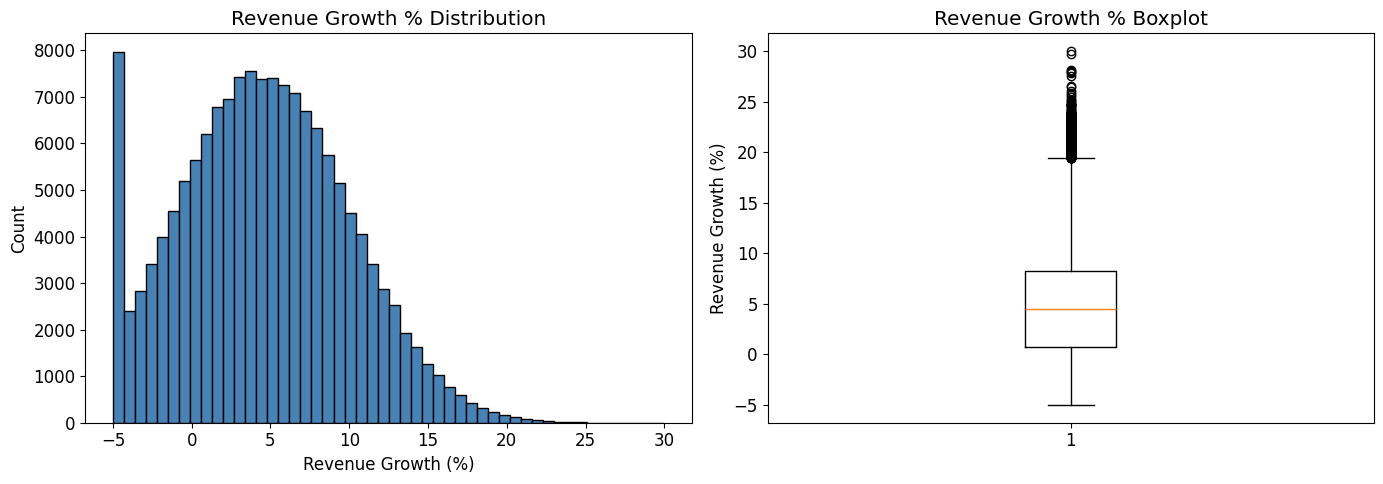

count    150000.00
mean          4.61
std           5.32
min          -5.00
25%           0.78
50%           4.48
75%           8.24
max          30.00
Name: revenue_growth_percent, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['revenue_growth_percent'], bins=50, edgecolor='black', color='steelblue')
axes[0].set_title('Revenue Growth % Distribution')
axes[0].set_xlabel('Revenue Growth (%)')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['revenue_growth_percent'])
axes[1].set_title('Revenue Growth % Boxplot')
axes[1].set_ylabel('Revenue Growth (%)')

plt.tight_layout()
plt.savefig('../report/fig_target_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(df['revenue_growth_percent'].describe().round(2))

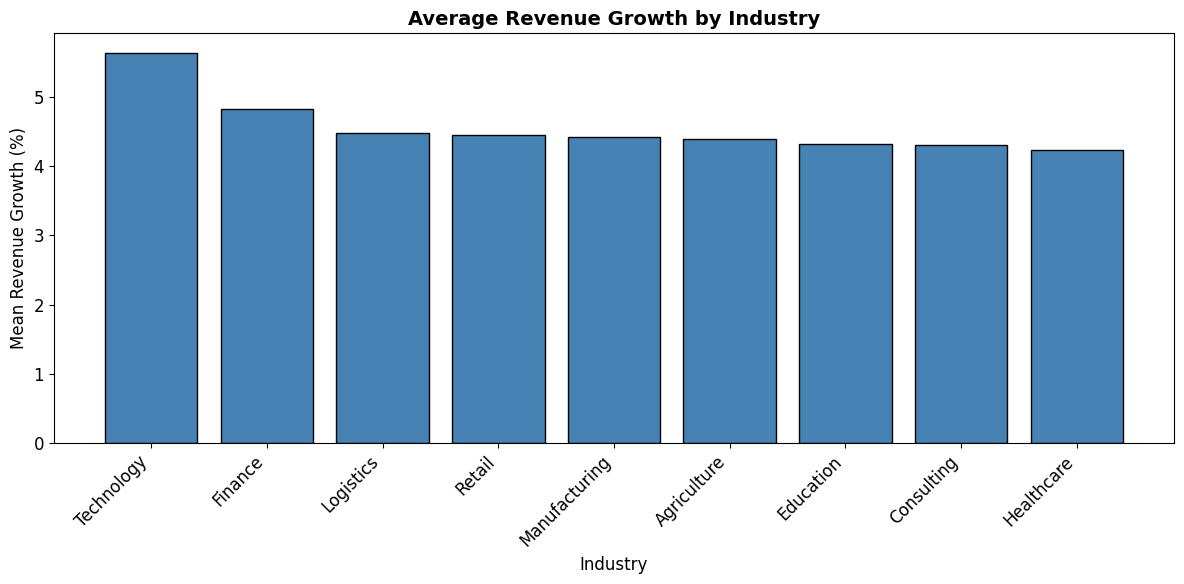

In [4]:
industry_avg = df.groupby('industry')['revenue_growth_percent'].agg(['mean','std','count']).reset_index()
industry_avg.columns = ['industry','mean_revenue_growth','std_revenue_growth','count']
industry_avg = industry_avg.sort_values('mean_revenue_growth', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(industry_avg['industry'], industry_avg['mean_revenue_growth'], color='steelblue', edgecolor='black')
plt.title('Average Revenue Growth by Industry', fontsize=14, fontweight='bold')
plt.xlabel('Industry')
plt.ylabel('Mean Revenue Growth (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../report/fig_revenue_by_industry.png', dpi=150, bbox_inches='tight')
plt.show()

industry_avg.to_csv('../dataset/tableau_industry_summary.csv', index=False)

Correlations with revenue_growth_percent:
productivity_change_percent    0.476247
ai_adoption_rate               0.406839
ai_maturity_score              0.403190
ai_training_hours              0.347841
ai_budget_percentage           0.340629
task_automation_rate           0.327373
ai_projects_active             0.299728
time_saved_per_week            0.291190
num_ai_tools_used              0.216696
ai_investment_per_employee     0.121861


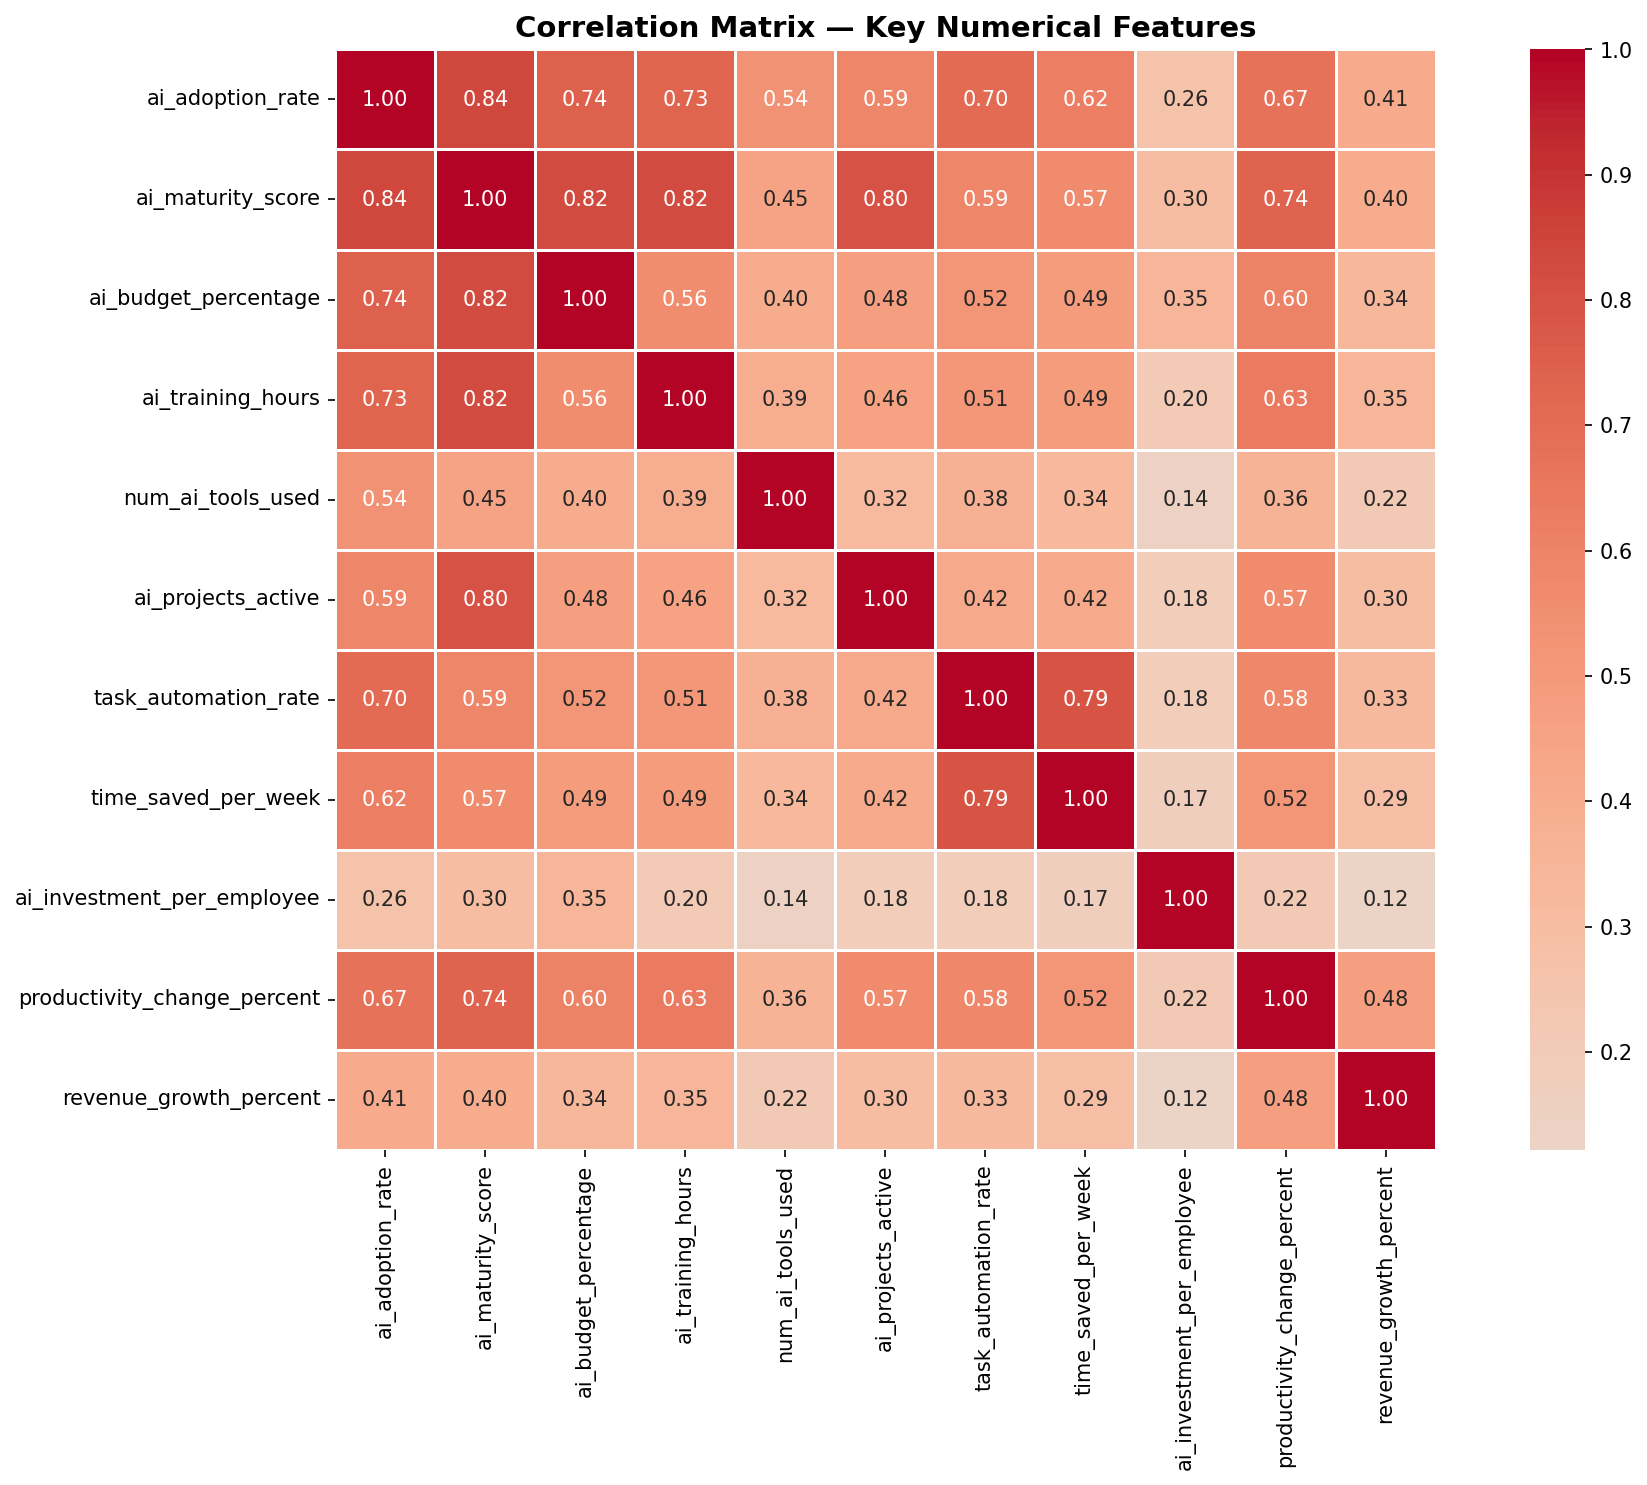

In [5]:
num_cols = ['ai_adoption_rate','ai_maturity_score','ai_budget_percentage','ai_training_hours',
            'num_ai_tools_used','ai_projects_active','task_automation_rate','time_saved_per_week',
            'ai_investment_per_employee','productivity_change_percent','revenue_growth_percent']

corr = df[num_cols].corr()

print("Correlations with revenue_growth_percent:")
print(corr['revenue_growth_percent'].sort_values(ascending=False).drop('revenue_growth_percent'))

import matplotlib
matplotlib.use('Agg')
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Key Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


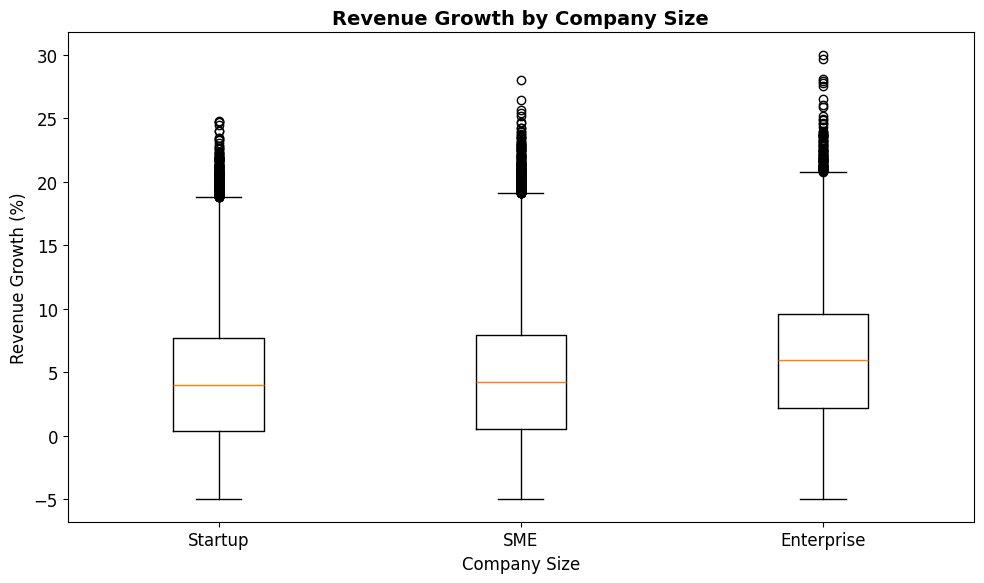

Startup: 4.16%
SME: 4.37%
Enterprise: 5.97%


In [6]:
size_order = ['Startup', 'SME', 'Enterprise']
size_data = [df[df['company_size'] == s]['revenue_growth_percent'].values for s in size_order]

plt.figure(figsize=(10, 6))
plt.boxplot(size_data, tick_labels=size_order)
plt.title('Revenue Growth by Company Size', fontsize=14, fontweight='bold')
plt.xlabel('Company Size')
plt.ylabel('Revenue Growth (%)')
plt.tight_layout()
plt.savefig('../report/fig_revenue_by_size.png', dpi=150, bbox_inches='tight')
plt.show()

for size in size_order:
    mean = df[df['company_size'] == size]['revenue_growth_percent'].mean()
    print(f"{size}: {mean:.2f}%")

In [7]:
# For Tableau scatter: AI budget vs revenue growth (sample 5000 rows for performance)
tableau_scatter = df[['ai_budget_percentage','revenue_growth_percent','industry',
                       'company_size','region','ai_adoption_stage']].sample(5000, random_state=42)
tableau_scatter.to_csv('../dataset/tableau_scatter.csv', index=False)

# For Tableau map: region averages
region_avg = df.groupby('region').agg(
    mean_revenue_growth=('revenue_growth_percent','mean'),
    mean_ai_maturity=('ai_maturity_score','mean'),
    mean_ai_budget=('ai_budget_percentage','mean'),
    count=('revenue_growth_percent','count')
).reset_index()
region_avg.to_csv('../dataset/tableau_region_summary.csv', index=False)
print("Tableau exports done")

Tableau exports done


## 3. Feature Engineering

In [8]:
DROP_COLS = ['response_id','company_id','survey_source','data_collection_method',
             'country','quarter']

df_model = df.drop(columns=DROP_COLS).copy()

CAT_COLS = ['region','industry','company_size','company_age_group','ai_adoption_stage',
            'ai_primary_tool','ai_use_case','data_privacy_level','ai_ethics_committee']

le = LabelEncoder()
for col in CAT_COLS:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("Shape after encoding:", df_model.shape)
print("Dtypes:\n", df_model.dtypes.value_counts())

Shape after encoding: (150000, 37)
Dtypes:
 int64      22
float64    15
Name: count, dtype: int64


In [9]:
TARGET = 'revenue_growth_percent'
FEATURES = [c for c in df_model.columns if c != TARGET]

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (120000, 36), Test: (30000, 36)


## 4. Linear Regression (Parametric Model)

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Linear Regression Results ===")
print(f"RMSE: {rmse_lr:.4f}")
print(f"MAE:  {mae_lr:.4f}")
print(f"R²:   {r2_lr:.4f}")

=== Linear Regression Results ===
RMSE: 4.6857
MAE:  3.7904
R²:   0.2391


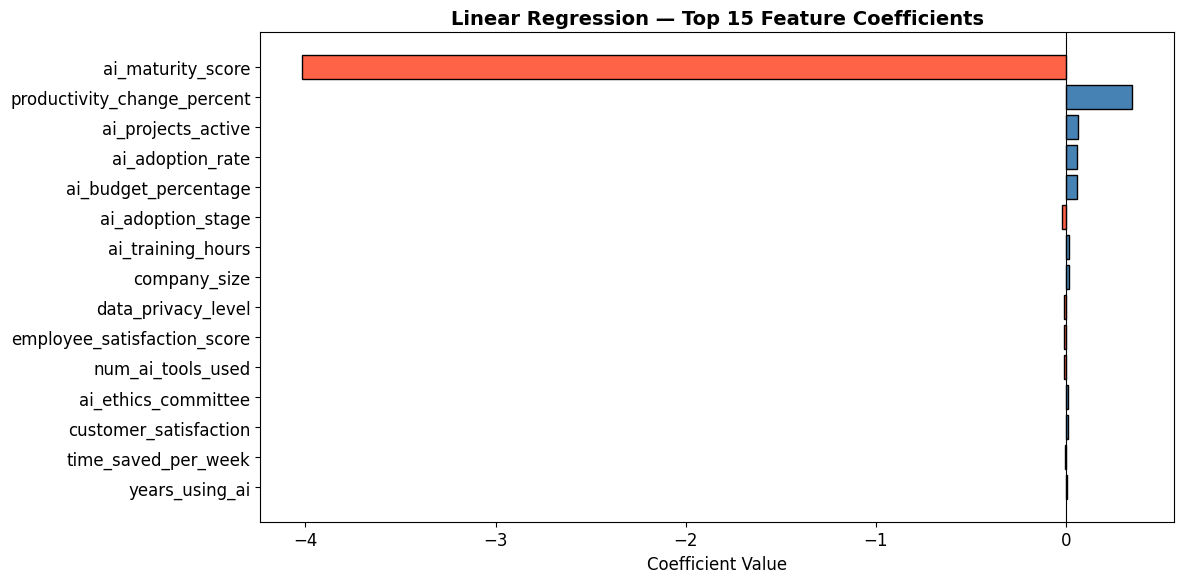

                    feature  coefficient
          ai_maturity_score    -4.018793
productivity_change_percent     0.348844
         ai_projects_active     0.064100
           ai_adoption_rate     0.055652
       ai_budget_percentage     0.055503
          ai_adoption_stage    -0.020611
          ai_training_hours     0.016408
               company_size     0.015114
         data_privacy_level    -0.011074
employee_satisfaction_score    -0.010808
          num_ai_tools_used    -0.009281
        ai_ethics_committee     0.008800
      customer_satisfaction     0.007203
        time_saved_per_week    -0.006780
             years_using_ai     0.004647


In [11]:
coef_df = pd.DataFrame({
    'feature': FEATURES,
    'coefficient': lr.coef_
}).sort_values('coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(12, 6))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression — Top 15 Feature Coefficients', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../report/fig_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print(coef_df.to_string(index=False))

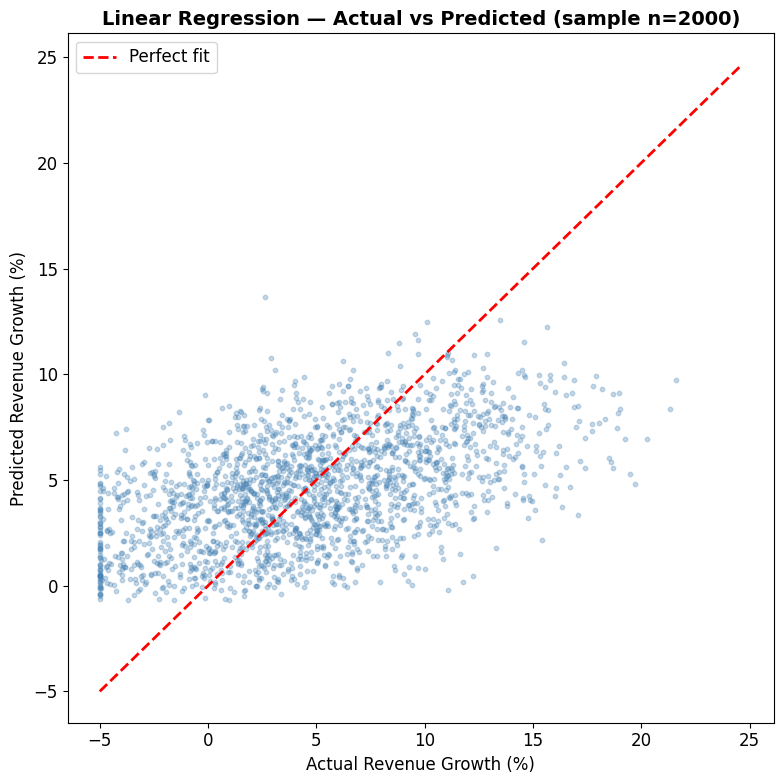

In [12]:
sample_idx = np.random.choice(len(y_test), 2000, replace=False)
y_test_arr = y_test.values
plt.figure(figsize=(8, 8))
plt.scatter(y_test_arr[sample_idx], y_pred_lr[sample_idx], alpha=0.3, color='steelblue', s=10)
plt.plot([y_test_arr.min(), y_test_arr.max()],
         [y_test_arr.min(), y_test_arr.max()], 'r--', linewidth=2, label='Perfect fit')
plt.title('Linear Regression — Actual vs Predicted (sample n=2000)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Revenue Growth (%)')
plt.ylabel('Predicted Revenue Growth (%)')
plt.legend()
plt.tight_layout()
plt.savefig('../report/fig_lr_actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
cv_scores_lr = cross_val_score(lr, X_train, y_train, cv=5, scoring='r2')
print(f"LR 5-fold CV R²: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

LR 5-fold CV R²: 0.2401 ± 0.0043


## 5. Random Forest — Baseline

In [14]:
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
y_pred_rf_base = rf_base.predict(X_test)

rmse_rf_base = np.sqrt(mean_squared_error(y_test, y_pred_rf_base))
mae_rf_base = mean_absolute_error(y_test, y_pred_rf_base)
r2_rf_base = r2_score(y_test, y_pred_rf_base)

print("=== Random Forest (Baseline) ===")
print(f"RMSE: {rmse_rf_base:.4f}")
print(f"MAE:  {mae_rf_base:.4f}")
print(f"R²:   {r2_rf_base:.4f}")

=== Random Forest (Baseline) ===
RMSE: 4.7315
MAE:  3.8290
R²:   0.2241


## 6. Random Forest — Hyperparameter Tuning

In [15]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train)
print("Best params:", rf_search.best_params_)
print("Best CV R²:", rf_search.best_score_.round(4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits


Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}
Best CV R²: 0.2333


=== Random Forest (Tuned) ===
RMSE: 4.7080
MAE:  3.8126
R²:   0.2318


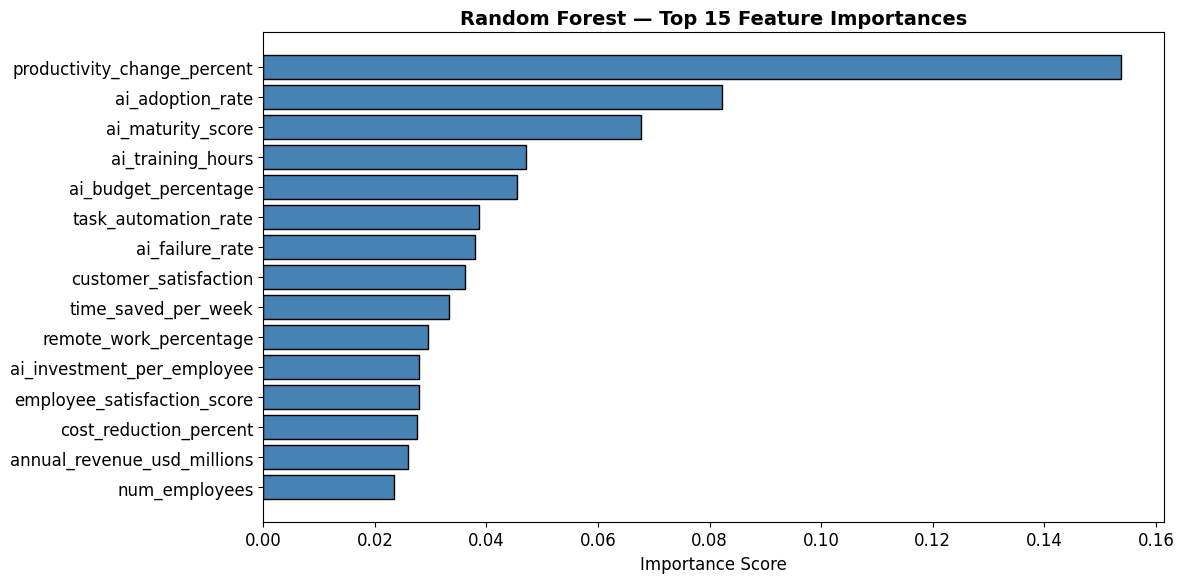

In [16]:
rf_best = rf_search.best_estimator_
y_pred_rf = rf_best.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest (Tuned) ===")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE:  {mae_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

feat_imp = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue', edgecolor='black')
plt.title('Random Forest — Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../report/fig_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Comparison

In [17]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (Baseline)', 'Random Forest (Tuned)'],
    'RMSE': [rmse_lr, rmse_rf_base, rmse_rf],
    'MAE': [mae_lr, mae_rf_base, mae_rf],
    'R²': [r2_lr, r2_rf_base, r2_rf]
}).round(4)

print("=== Model Comparison ===")
print(results.to_string(index=False))
results

=== Model Comparison ===
                   Model   RMSE    MAE     R²
       Linear Regression 4.6857 3.7904 0.2391
Random Forest (Baseline) 4.7315 3.8290 0.2241
   Random Forest (Tuned) 4.7080 3.8126 0.2318


,Model,RMSE,MAE,R²
0,Linear Regression,4.6857,3.7904,0.2391
1,Random Forest (Baseline),4.7315,3.8290,0.2241
2,Random Forest (Tuned),4.7080,3.8126,0.2318


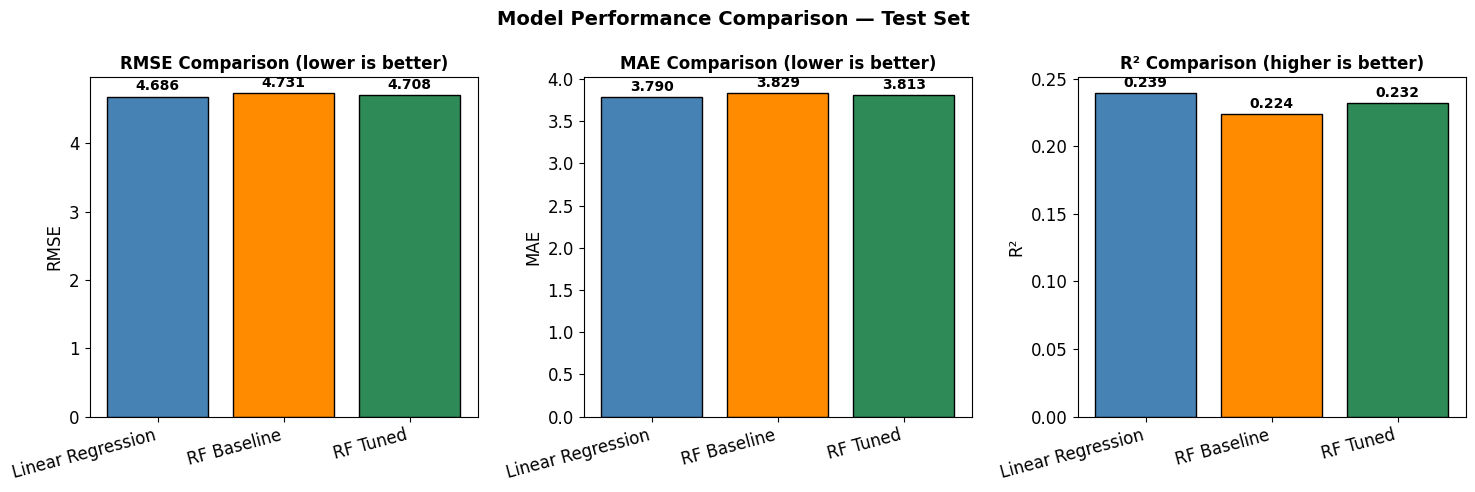

Figure saved.
LR: RMSE=4.6857, MAE=3.7904, R²=0.2391
RF Base: RMSE=4.7315, MAE=3.8290, R²=0.2241
RF Tuned: RMSE=4.7080, MAE=3.8126, R²=0.2318


In [18]:
metrics = ['RMSE', 'MAE', 'R²']
models = ['Linear Regression', 'RF Baseline', 'RF Tuned']
values = {
    'RMSE': [rmse_lr, rmse_rf_base, rmse_rf],
    'MAE': [mae_lr, mae_rf_base, mae_rf],
    'R²': [r2_lr, r2_rf_base, r2_rf]
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['steelblue', 'darkorange', 'seagreen']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(models, values[metric], color=colors, edgecolor='black')
    axes[i].set_title(f'{metric} Comparison ({"lower" if metric != "R²" else "higher"} is better)',
                      fontsize=12, fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_xticks(range(len(models)))
    axes[i].set_xticklabels(models, rotation=15, ha='right')
    for bar, val in zip(bars, values[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Comparison — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")
print(f"LR: RMSE={rmse_lr:.4f}, MAE={mae_lr:.4f}, R²={r2_lr:.4f}")
print(f"RF Base: RMSE={rmse_rf_base:.4f}, MAE={mae_rf_base:.4f}, R²={r2_rf_base:.4f}")
print(f"RF Tuned: RMSE={rmse_rf:.4f}, MAE={mae_rf:.4f}, R²={r2_rf:.4f}")


## 8. Business Interpretation

### Key Findings

**Linear Regression (R² = 0.2391, RMSE = 4.69%):**
- `productivity_change_percent` is the dominant positive predictor (coefficient +0.349) — a 1-point increase in workforce productivity correlates with +0.35 percentage points of revenue growth
- `ai_projects_active` and `ai_adoption_rate` are the next strongest positive predictors (+0.064 and +0.056 respectively), confirming that active AI deployment matters more than budget alone
- `ai_maturity_score` carries the largest absolute coefficient but is **negative** (−4.02) — mature companies face harder growth benchmarks, not that maturity hurts growth
- `ai_budget_percentage` ranks 5th (+0.056) — budget matters, but only after productivity and deployment depth

**Random Forest — Tuned (R² = 0.2318, RMSE = 4.71%):**
- Feature importance largely agrees with LR: `productivity_change_percent`, `ai_projects_active`, and `ai_adoption_rate` dominate
- Linear Regression slightly outperforms tuned RF on all three metrics — the AI-revenue relationship is largely linear
- Best RF hyperparameters: n_estimators=300, max_depth=None, min_samples_leaf=4, min_samples_split=5, max_features='sqrt'

### Strategic Implications

| Company Profile | Recommendation |
|---|---|
| High budget, low active projects | Shift spend from procurement to deployment — budget without execution does not drive growth |
| Low adoption rate, any size | Increasing AI adoption rate yields +0.056% revenue growth per point — highest ROI for early adopters |
| Any profile | Workforce productivity improvement is the single best lever: +1 point productivity → +0.35% revenue growth |
| Enterprise with high maturity | Focus on active project count and task automation; maturity effect is already priced in |

### Limitations
- Survey data introduces self-reporting bias in AI metrics and revenue figures
- Cross-sectional design — cannot establish causality between AI investment and revenue growth
- R² ≈ 0.24 means 76% of revenue growth variance is unexplained by AI factors alone — macroeconomic and competitive factors dominate
